# FITTING NOTEBOOK

In [2]:
# ALWAYS RUN THE FIRST THREE CELLS
import juliet
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pickle
import corner
import transitspectroscopy as ts
from tqdm import tqdm
import pandas as pd

import seaborn as sns
sns.set_style('ticks')

In [3]:
# Open data file (transitspectroscopy output)
path = '/media/peng/KINGSTON/'
with open(path + '_jw03385002001_toi1130_nrs2_spectrum.pkl', 'rb') as file:
    data = pickle.load(file)

# data is a dict with 7 entries: 
# 1. metadata: Information about instrument and detector, ex. name: NIRSpec, detector: NRS1
# 2. & 3. tso & tso_err: Not sure, just a bunch of zeroes as far as I can see
# 4. traces: Contains times in random order, x, ycorrected, ysmoothed
# 5 spectra: Contains times in increasing order, original + original_err, corrected + corrected_err, wavelength map (a bunch of nans) and wavelengths that the detector measures
# --> IMPORTANT: data['spectra']['corrected'] and corrected_err contain each spectroscopic lc for the corresponding wavelength in ppm (more detail in next section)
# 6 & 7. whitelight & whitelight_err: Relative flux for white light curve and its errorbars

In [4]:
# Define planetary parameters
per = 4.074554             # Period (Days)
t0 = 2460543.0635          # Mid-Transit Time (BJD)
a = 13.77                  # Semimajor Axis (a/R*)
b = -0.518                 # Impact Parameter
ecc = 0.052162             # Eccentricity
omega = 141.11             # Argument of Periastron (Degrees)

# Define planet and instrument name
star = 'TOI-1130'
pn = 'TOI-1130b'
itm = 'NRS2'

# White Light Curves

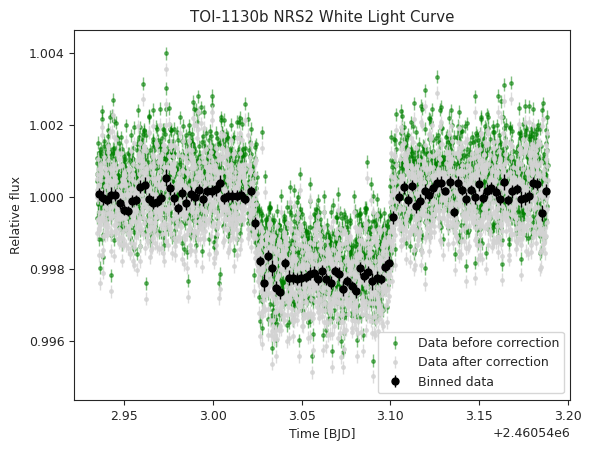

In [4]:
# Define time and flux data points - white light curves
t = data['spectra']['times']
f_wl = data['whitelight']
ferr_wl = data['whitelight_err']

plt.errorbar(t, f_wl, yerr = ferr_wl, fmt = '.', color = 'g', ms = 5, elinewidth = 1, alpha = 0.5, label = 'Data before correction', zorder = 1)

# Normalize flux such that the out-of-transit flux = 1
f_med = np.nanmedian(f_wl[:100])
f_wl, ferr_wl = f_wl / f_med, ferr_wl / f_med
tbin, fbin, ferrbin = juliet.bin_data(t, f_wl, 25)

plt.errorbar(t, f_wl, yerr = ferr_wl, fmt = '.', color = 'lightgrey', ms = 5, elinewidth = 1, alpha = 0.8, label = 'Data after correction', zorder = 5)
plt.errorbar(tbin, fbin, yerr = ferrbin, fmt = '.', color = 'k', ms = 10, elinewidth = 1, label = 'Binned Data', zorder = 10)

plt.title(pn+' '+itm+ ' White Light Curve')
plt.xlabel('Time [BJD]')
plt.ylabel('Relative flux')

# Define root-mean-squared values
rms = ts.utils.get_mad_sigma(np.median(f_wl[: 100] - 1.), f_wl[: 100] - 1.) * 1e6
rms_predicted = np.median(ferr_wl[: 100]) * 1e6

plt.legend()
plt.show()

In [5]:
# Define standardized regressors for linear and/or GP fits
def standardized_regressors(x):
    return (x - np.mean(x)) / np.sqrt(np.var(x))

regressors = np.zeros([len(t), 1])   # Array with len(t) rows and 1 column
regressors[:, 0] = standardized_regressors(t)

In [6]:
# Define parameters - comment out all sets except for one

# # Just transit
# params = ['P_p1', 't0_p1', 'a_p1', 'b_p1', 'u1_'+itm, 'u2_'+itm, 'ecc_p1', 'omega_p1', 'p_p1',
#           'mdilution_'+itm, 'mflux_'+itm, 'sigma_w_'+itm]

# dists = ['fixed', 'normal', 'fixed', 'fixed', 'uniform', 'uniform', 'fixed', 'fixed', 'uniform',
#          'fixed', 'normal', 'loguniform']

# hyperps = [per, [t0, 0.2], a, b, [-3., 3.], [-3., 3.], ecc, omega, [0., 0.2],
#            1.0, [0., 0.1], [10., 1000.]]
# #--------------------------------------------------------------------------------------------------

# Linear
params = ['P_p1', 't0_p1', 'a_p1', 'b_p1', 'u1_'+itm, 'u2_'+itm, 'ecc_p1', 'omega_p1', 'p_p1',
          'mdilution_'+itm, 'mflux_'+itm, 'sigma_w_'+itm, 
          'theta0_'+itm]

dists = ['fixed', 'normal', 'fixed', 'fixed', 'uniform', 'uniform', 'fixed', 'fixed', 'uniform',
         'fixed', 'normal', 'loguniform',
         'uniform']

hyperps = [per, [t0, 0.2], a, b, [-3., 3.], [-3., 3.], ecc, omega, [0., 0.2],
           1.0, [0., 0.1], [10., 1000.], 
          [-10, 10]]
# #--------------------------------------------------------------------------------------------------

# # GP
# params =  ['P_p1', 't0_p1','a_p1','b_p1', 'u1_'+itm, 'u2_'+itm ,'ecc_p1','omega_p1', 'p_p1',
#            'mdilution_'+itm, 'mflux_'+itm, 'sigma_w_'+itm, 
#            'GP_sigma_'+itm, 'GP_rho_'+itm]

# dists = ['fixed', 'normal', 'fixed', 'fixed', 'uniform', 'uniform', 'fixed', 'fixed', 'uniform',
#          'fixed', 'normal', 'loguniform',
#          'loguniform', 'loguniform']

# hyperps = [per, [t0, 0.2], a, b, [-3., 3.], [-3., 3.], ecc, omega, [0., 0.2],
#            1.0, [0., 0.1], [10., 1000.], 
#            [1e-8, 1e2], [1e-8, 1e3]]
#--------------------------------------------------------------------------------------------------

# Linear + GP
# params =  ['P_p1', 't0_p1','a_p1','b_p1', 'u1_'+itm, 'u2_'+itm ,'ecc_p1','omega_p1', 'p_p1',
#            'mdilution_'+itm, 'mflux_'+itm, 'sigma_w_'+itm, 
#            'theta0_'+itm, 'GP_sigma_'+itm, 'GP_rho_'+itm]

# dists = ['fixed', 'normal', 'fixed', 'fixed', 'uniform', 'uniform', 'fixed', 'fixed', 'uniform',
#          'fixed', 'normal', 'loguniform',
#          'uniform', 'loguniform', 'loguniform']

# hyperps = [per, [t0, 0.2], a, b, [-3., 3.], [-3., 3.], ecc, omega, [0., 0.2],
#            1.0, [0., 0.1], [10., 1000.], 
#            [-10, 10], [1e-6, 1e6], [1e-3, 1e3]]


priors = juliet.generate_priors(params, dists, hyperps) 

In [7]:
# Put data into dictionaries to feed into juliet
times, fluxes, fluxes_err, linear_regressors, GP_regressors = {}, {}, {}, {}, {}
times[itm], fluxes[itm], fluxes_err[itm] = t, f_wl, ferr_wl
linear_regressors[itm] = regressors
GP_regressors[itm] = regressors

# Load dataset and run sampler, again comment out everything except for the one you're running

# # Just transit
# dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = fluxes_err, 
#                  ld_laws = 'quadratic', out_folder = pn+'_'+itm+'_wlcfit')
# #---------------------------------------------------------------------------------------------

# Linear
dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = fluxes_err, 
                 linear_regressors_lc = linear_regressors,
                 ld_laws = 'quadratic', out_folder = pn+'_'+itm+'_wlcfit_linear')
# #---------------------------------------------------------------------------------------------

# # GP
# dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = fluxes_err, 
#                  GP_regressors_lc = GP_regressors,
#                  ld_laws = 'quadratic', out_folder = pn+'_'+itm+'_wlcfit_GP')
#---------------------------------------------------------------------------------------------

# # Linear + GP
# dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = fluxes_err, 
#                  linear_regressors_lc = linear_regressors, GP_regressors_lc = GP_regressors,
#                  ld_laws = 'quadratic', out_folder = pn+'_'+itm+'_wlcfit_linear+GP')

results = dataset.fit(sampler = 'dynamic_dynesty', nthreads = 3, verbose = True, n_live_points = 1000)
print('done')

Detected dynamic_dynesty sampler output files --- extracting from TOI-1130b_NRS2_wlcfit_linear/_dynesty_DNS_posteriors.pkl
done


In [8]:
# Take jitter values from posterior and multiply into errors
sigma = np.median(results.posteriors['posterior_samples']['sigma_w_'+itm] * 1e-6)
mflux = np.median(results.posteriors['posterior_samples']['mflux_'+itm])
total_errors = np.sqrt(sigma**2 + ferr_wl**2)

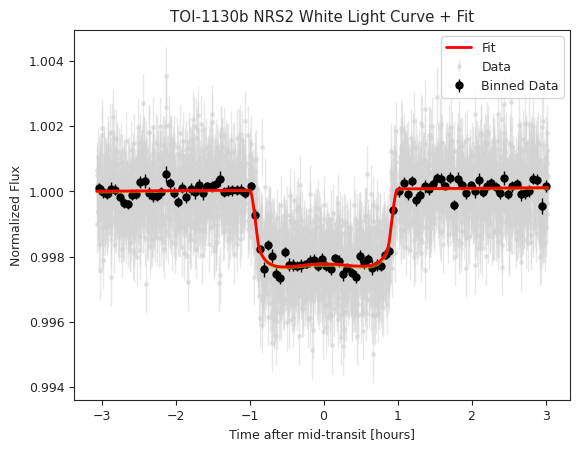

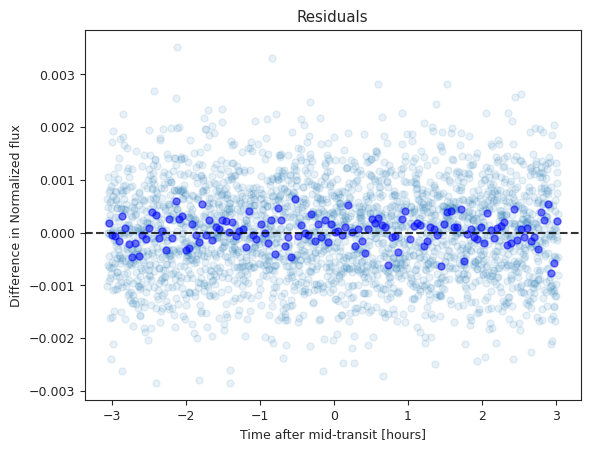

In [9]:
# Normalize time so that it's relative to best-fit mid-transit and make some plots
mid_t = np.nanmedian(results.posteriors['posterior_samples']['t0_p1'])
norm_t = (t - mid_t) * 24
norm_tbin = (tbin - mid_t) * 24

# Scatter data
plt.errorbar(norm_t, f_wl, yerr = total_errors, fmt = '.', color = 'lightgrey', ms = 5, elinewidth = 1, label = 'Data', alpha = 0.5, zorder = 1)
plt.errorbar(norm_tbin, fbin, yerr = ferrbin, fmt = '.', color = 'k', ms = 10, elinewidth = 1, label = 'Binned Data', zorder = 5)

# Get best fit and +/- 1 sigma band from posterior, then plot
transit_model, transit_up68, transit_low68 = results.lc.evaluate(itm, return_err = True)

plt.plot(norm_t, transit_model, color = 'r', lw = 2, label = 'Fit', zorder = 10)
plt.fill_between(norm_t, transit_up68, transit_low68, color = 'y', alpha = 0.5, zorder = 8)

plt.title(pn+' '+itm+ ' White Light Curve + Fit')
plt.xlabel('Time after mid-transit [hours]')
plt.ylabel('Normalized Flux')
plt.legend()
plt.show()

# Residuals plot
resid = f_wl - transit_model
resid_binx, resid_biny, _ = juliet.bin_data(norm_t, resid, 20)

plt.scatter(norm_t, resid, alpha = 0.1, zorder = 1)
plt.scatter(resid_binx, resid_biny, alpha = 0.5, color = 'b', zorder = 5)
plt.axhline(y = 0, ls = '--', color = 'k', alpha = 0.8, zorder = 10)

plt.title('Residuals')
plt.xlabel('Time after mid-transit [hours]')
plt.ylabel('Difference in Normalized Flux')
plt.show()

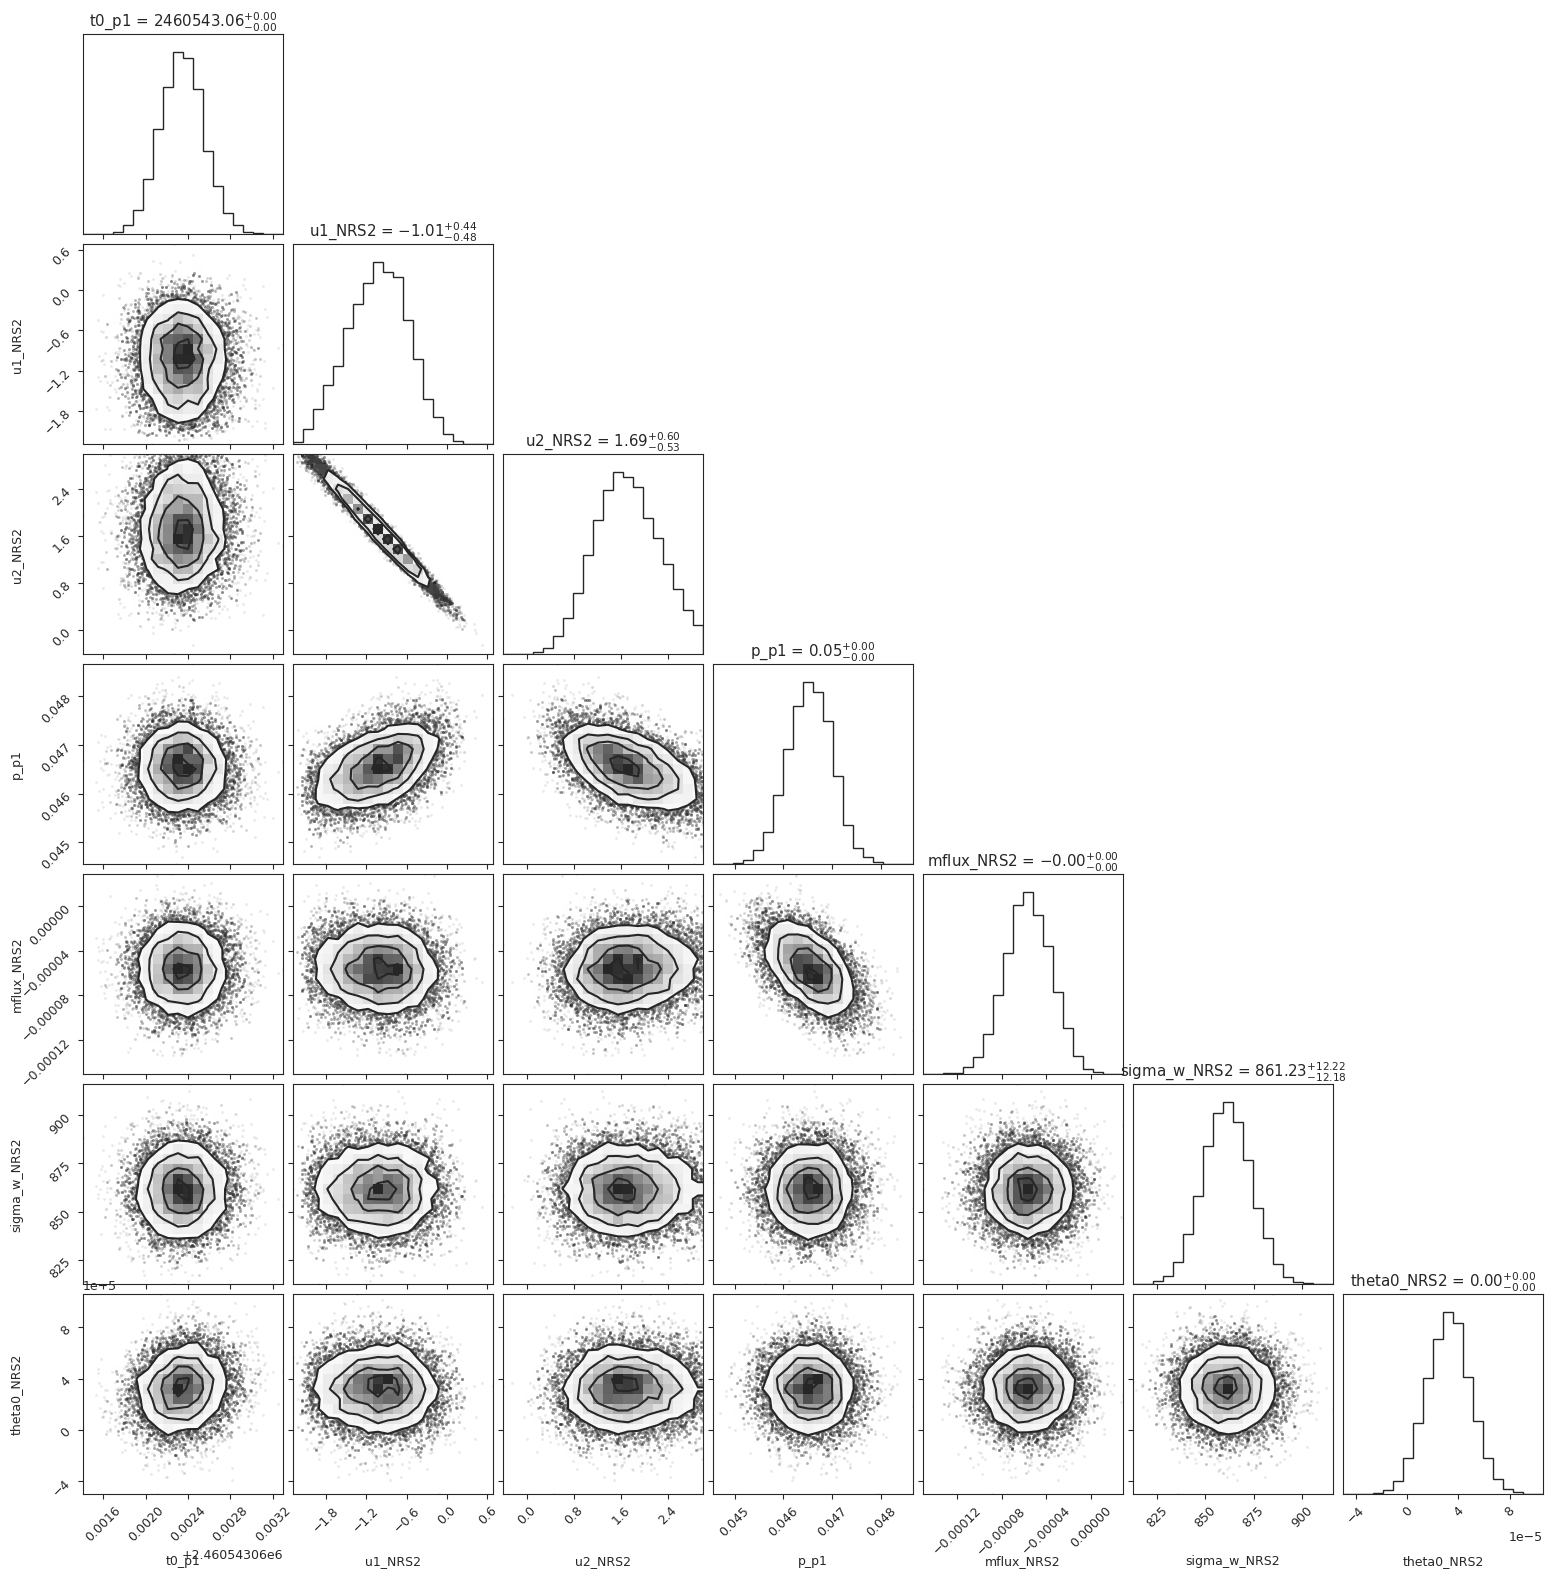

In [10]:
# Corner plot
list_post = []
names = []
for f in results.posteriors['posterior_samples']:
    if f not in ['unnamed', 'loglike']:
        names.append(f)
        list_post.append(results.posteriors['posterior_samples'][f])
tr = np.array(list_post).T
corner.corner(tr, labels = names, show_titles=True,)
plt.show()

In [11]:
# Print log evidence, lnZ
# print('Without linear or GP:', results.posteriors['lnZ'])
print('With linear only:', results.posteriors['lnZ'])
# print('With GP only:', results.posteriors['lnZ'])
# print('With linear + GP:', results.posteriors['lnZ'])

With linear only: 14972.623838445552


# Spectroscopic Light Curves

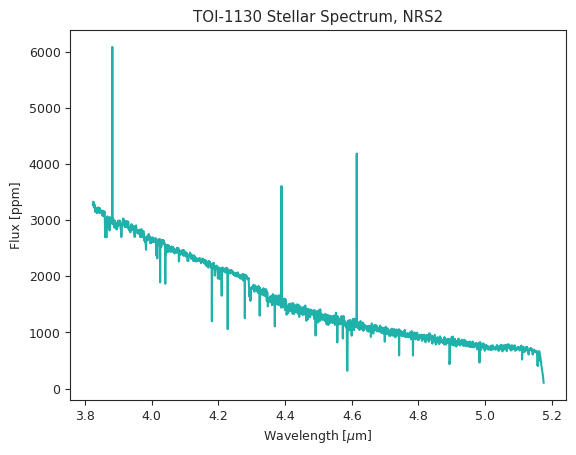

In [5]:
spectra = data['spectra']

# There are m times and n wavelengths
t = spectra['times']
wl = spectra['wavelengths']   

# Each spectra['corrected'] is a mxn array, where columns contain the corresponding spectroscopic light curve in ppm
slc, slcerr = spectra['corrected'], spectra['corrected_err']  

# We can plot corrected spectrum vs wavelength to see something that looks like the stellar spectrum
plt.plot(wl, slc[0], color = 'lightseagreen')
plt.title(star+' Stellar Spectrum, '+itm)
plt.xlabel('Wavelength [$\mu$m]')
plt.ylabel('Flux [ppm]')
plt.show()

# To format slc and slcerr to give fluxes at each wavelength, index them along a column
# For example f[i] = slc[:, i] gives the ith spectroscopic light curve corresponding to the ith wavelength

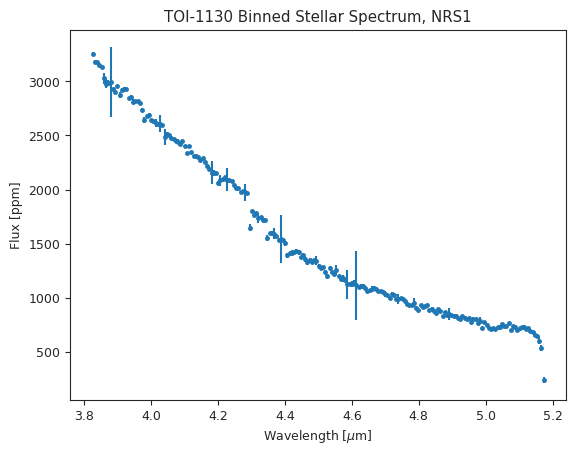

In [6]:
# Bin every 10 wavelengths and spectroscopic light curves
bin_slc, bin_slcerr = [] ,[]

for i in range(len(slc)):
    j, k, l = juliet.bin_data(wl, slc[i], 10)   # These are xbin, ybin, ybinerr for each column in slc
    bin_slc.append(k)
    bin_slcerr.append(l)
bin_wl = j     

# bin_wl is simply a list of all the binned wavelengths
# bin_slc and bin_slcerr are the same as slc and slcerr but now instead of mxn, they are mx(n/10) lists, again, where each column is a light curve
    
# # Optional: plot binned stellar spectrum (for the last timestamp)
plt.errorbar(j, k, yerr = l, fmt = '.')
plt.title(star+' Binned Stellar Spectrum, NRS1')
plt.xlabel('Wavelength [$\mu$m]')
plt.ylabel('Flux [ppm]')
plt.show()

bin_slc, bin_slcerr = np.array(bin_slc), np.array(bin_slcerr)

In [7]:
# Store all spectroscopic light curves in a dict, where each key is a wavelength whose value is another dict. In the nested dict, keys will be flux and flux error 
# --> spec_lcs = {wavelength 1: {flux: [...], err: [...]}, wavelength 2: {flux: [...], err: [...]}, ..., wavelength n: {flux: [...], err: [...]}}
# If you want to fit spectroscopic light curves to native resolutions, just call wl and slc instead of binned versions, then bin data points afterwards

spec_lcs = {}
for i in range(len(bin_wl)):
    wavelength = bin_wl[i]

    # Normalize each binned light curve 
    slc_med = np.nanmedian(bin_slc[:, i][:100])
    spec_lcs[wavelength] = {}
    spec_lcs[wavelength]['f'] = bin_slc[:, i] / slc_med
    spec_lcs[wavelength]['ferr'] = bin_slcerr[:, i] / slc_med

# Run next line for exact values, then put one of the outputs as trial_wl
# for i in spec_lcs:
#     print(i)

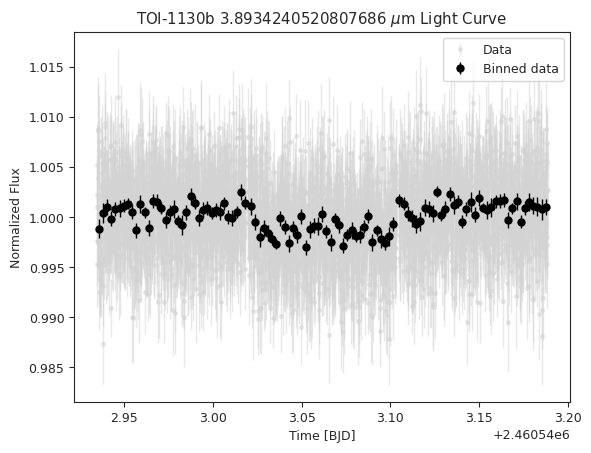

In [73]:
# Define time and flux data points - spectroscopic light curves
# For now, manually fit for 5 random points
# 3.826294540727768, 4.007334699042037, 4.154542456673429, 4.361259636259716, 4.805217904505658

trial_wl = 3.8934240520807686
t = t     # Sorry I just feel like defining time again for the billionth time
f_s = spec_lcs[trial_wl]['f']
ferr_s = spec_lcs[trial_wl]['ferr']

# Don't need to normalize since it's already normalized in the dict, so just bin
tbin, fsbin, ferrsbin = juliet.bin_data(t, f_s, 25)

plt.errorbar(t, f_s, yerr = ferr_s, fmt = '.', color = 'lightgrey', ms = 5, elinewidth = 1, alpha = 0.5, label = 'Data', zorder = 1)
plt.errorbar(tbin, fsbin, yerr = ferrsbin, fmt = '.', color = 'k', ms = 10, elinewidth = 1, label = 'Binned data', zorder = 10)
plt.title(pn+' '+str(trial_wl)+' $\mu$m Light Curve')
plt.xlabel('Time [BJD]')
plt.ylabel('Normalized Flux')
plt.legend()
plt.show()

In [74]:
# Define standardized regressors for linear and/or GP fits
def standardized_regressors(x):
    return (x - np.mean(x)) / np.sqrt(np.var(x))

regressors = np.zeros([len(t), 1])   # Array with len(t) rows and 1 column
regressors[:, 0] = standardized_regressors(t)

In [75]:
# For now, only define parameters + linear model for NRS1 and 2
# t0 = 2460543.0631091068 # for NRS1
t0 = 2460543.0623039217 # for NRS2

params = ['P_p1', 't0_p1', 'a_p1', 'b_p1', 'u1_'+itm, 'u2_'+itm, 'ecc_p1', 'omega_p1', 'p_p1',
          'mdilution_'+itm, 'mflux_'+itm, 'sigma_w_'+itm, 
          'theta0_'+itm]

dists = ['fixed', 'fixed', 'fixed', 'fixed', 'uniform', 'uniform', 'fixed', 'fixed', 'uniform',
         'fixed', 'normal', 'loguniform',
         'uniform']

hyperps = [per, t0, a, b, [-3., 3.], [-3., 3.], ecc, omega, [0., 0.2],
           1.0, [0., 0.1], [10., 1000.], 
          [-10, 10]]

priors = juliet.generate_priors(params, dists, hyperps)

# Put data into dictionaries
times, fluxes, fluxes_err, linear_regressors, GP_regressors = {}, {}, {}, {}, {}
times[itm], fluxes[itm], fluxes_err[itm] = t, f_s, ferr_s
linear_regressors[itm] = regressors
GP_regressors[itm] = regressors

# Load dataset and run sampler
dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = fluxes_err, 
                 linear_regressors_lc = linear_regressors,
                 ld_laws = 'quadratic', out_folder = pn+'_'+str(trial_wl)+'_fit')

results = dataset.fit(sampler = 'dynamic_dynesty', nthreads = 3, verbose = True, n_live_points = 1000)
print('done')

35863it [03:52, 154.28it/s, batch: 2 | bound: 1 | nc: 1 | ncall: 823058 | eff(%):  4.229 | loglstar: 11073.261 < 11077.444 < 11073.859 | logz: 11052.120 +/-  0.129 | stop:  0.880]            


done


In [76]:
# Take jitter values from posterior and multiply into errors
sigma = np.median(results.posteriors['posterior_samples']['sigma_w_'+itm] * 1e-6)
mflux = np.median(results.posteriors['posterior_samples']['mflux_'+itm])
total_errors = np.sqrt(sigma**2 + ferr_s**2)

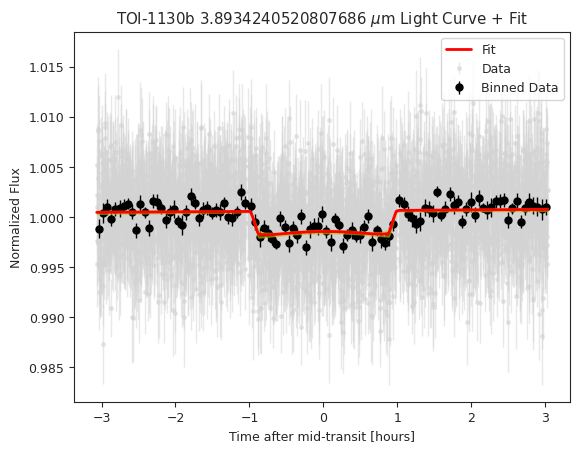

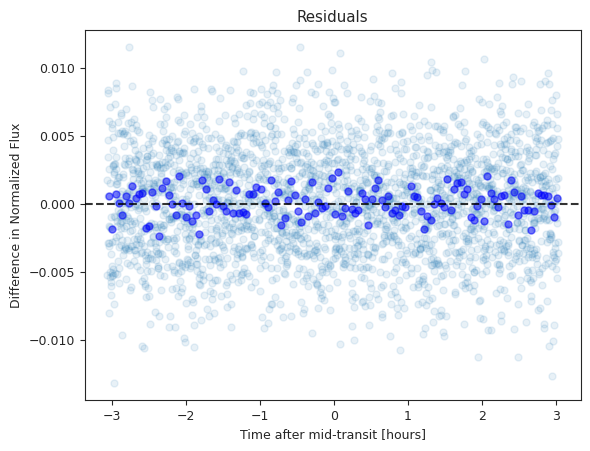

In [77]:
# Normalize time so it's relative to mid-transit
norm_t = (t - t0) * 24
norm_tbin = (tbin - t0) * 24

# Scatter data
plt.errorbar(norm_t, f_s, yerr = total_errors, fmt = '.', color = 'lightgrey', ms = 5, elinewidth = 1, label = 'Data', alpha = 0.5, zorder = 1)
plt.errorbar(norm_tbin, fsbin, yerr = ferrsbin, fmt = '.', color = 'k', ms = 10, elinewidth = 1, label = 'Binned Data', zorder = 5)

# Get best fit and +/- 1 sigma band from posterior, then plot
transit_model, transit_up68, transit_low68 = results.lc.evaluate(itm, return_err = True)

plt.plot(norm_t, transit_model, color = 'r', lw = 2, label = 'Fit', zorder = 10)
plt.fill_between(norm_t, transit_up68, transit_low68, color = 'y', alpha = 0.5, zorder = 8)

plt.title(pn+ ' '+str(trial_wl)+ ' $\mu$m Light Curve + Fit')
plt.xlabel('Time after mid-transit [hours]')
plt.ylabel('Normalized Flux')
plt.legend()
plt.show()

# Residuals plot
resid = f_s - transit_model
resid_binx, resid_biny, _ = juliet.bin_data(norm_t, resid, 20)

plt.scatter(norm_t, resid, alpha = 0.1, zorder = 1)
plt.scatter(resid_binx, resid_biny, alpha = 0.5, color = 'b', zorder = 5)
plt.axhline(y = 0, ls = '--', color = 'k', alpha = 0.8, zorder = 10)

plt.title('Residuals')
plt.xlabel('Time after mid-transit [hours]')
plt.ylabel('Difference in Normalized Flux')
plt.show()

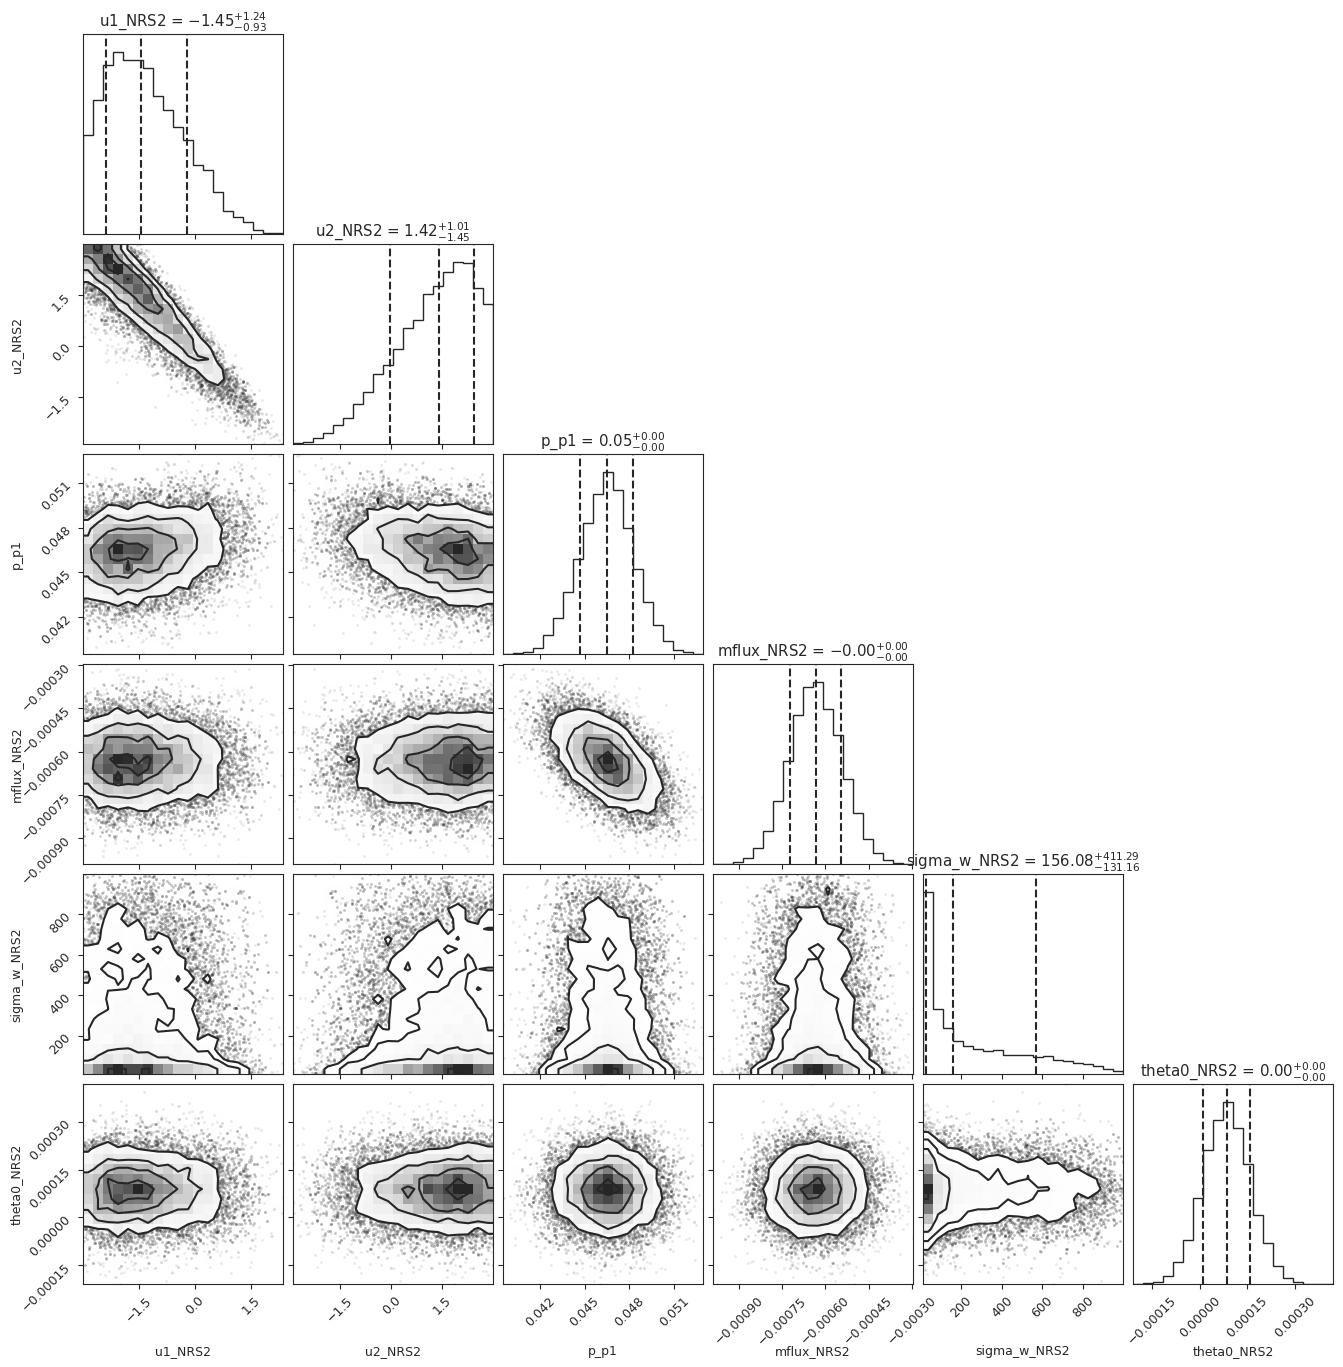

Log Evidence: 11052.131000773068


In [85]:
# Corner plot
list_post = []
names = []
for f in results.posteriors['posterior_samples']:
    if f not in ['unnamed', 'loglike']:
        names.append(f)
        list_post.append(results.posteriors['posterior_samples'][f])
tr = np.array(list_post).T
corner.corner(tr, labels = names, show_titles=True, quantiles = [0.16, 0.50, 0.84])
plt.show()

print('Log Evidence:', results.posteriors['lnZ'])

In [79]:
# Get best fit value of p_p1 and convert to transit depth
rp_list = results.posteriors['posterior_samples']['p_p1']
best_rp, max_rp, min_rp = np.nanmedian(rp_list), np.max(rp_list), np.min(rp_list)

td, td_up, td_low = (best_rp**2) * 100, (max_rp**2) * 100, (min_rp**2) * 100
tderr = np.array([[td - td_low], [td_up - td]])

fake1, fake2 = best_rp - min_rp, max_rp - best_rp
fake1, fake2 = (fake1**2)*100, (fake2**2)*100
asdf = np.array([[fake1], [fake2]])
print('Wavelength:', trial_wl, '\n',
      'Transit Depth:', td, '\n', 
      'Errors:', tderr)

Wavelength: 3.8934240520807686 
 Transit Depth: 0.2163311964514808 
 Errors: [[0.06009712]
 [0.06408277]]


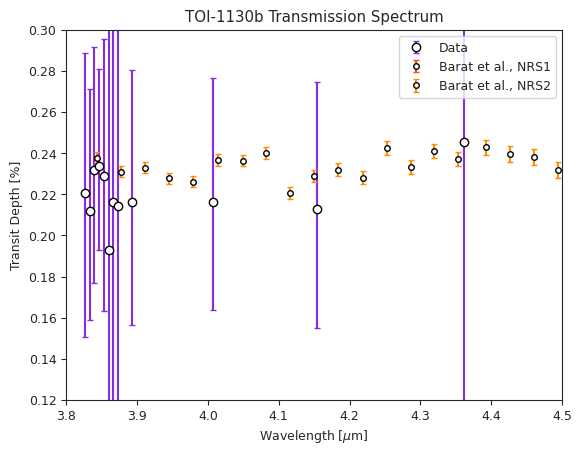

In [84]:
# Load spectrum from Barat et al., 2026 for comparison
barat_nrs1 = pd.read_csv('barat_toi1130b_spectrum_nrs1.csv')
barat_wl_nrs1 = barat_nrs1['CENTRALWAVELNG']
barat_td_nrs1 = barat_nrs1['PL_TRANDEP']
barat_tderr_nrs1 = barat_nrs1['PL_TRANDEPERR1']

barat_nrs2 = pd.read_csv('barat_toi1130b_spectrum_nrs2.csv')
barat_wl_nrs2 = barat_nrs2['CENTRALWAVELNG']
barat_td_nrs2 = barat_nrs2['PL_TRANDEP']
barat_tderr_nrs2 = barat_nrs2['PL_TRANDEPERR1']

# Plot spectra
plt.errorbar(3.826294540727768, 0.2207451338727178, yerr = [[0.0703274 ], [0.06796333]], 
             fmt = 'o', capsize = 2, ms = 6, mfc = 'w', mec = 'k', color = 'blueviolet', label = 'Data')
plt.errorbar(4.007334699042037 , 0.21632418152116067, yerr = [[0.05286257], [0.06019445]], 
             fmt = 'o', capsize = 2, ms = 6, mfc = 'w', mec = 'k', color = 'blueviolet')
plt.errorbar(4.154542456673429, 0.2126965397295762, yerr = [[0.05754311], [0.06197533]], 
             fmt = 'o', capsize = 2, ms = 6, mfc = 'w', mec = 'k', color = 'blueviolet')             
plt.errorbar(4.361259636259716, 0.2456046173203343, yerr = [[0.18001918], [0.19710804]], 
             fmt = 'o', capsize = 2, ms = 6, mfc = 'w', mec = 'k', color = 'blueviolet')
plt.errorbar(4.805217904505658, 0.19474365296451496, yerr = [[0.15290068], [0.15931335]], 
             fmt = 'o', capsize = 2, ms = 6, mfc = 'w', mec = 'k', color = 'blueviolet')

# Some adjacent points
plt.errorbar(3.833010306703474, 0.21198494816218605, yerr = [[0.05294764], [0.05953068]], 
             fmt = 'o', capsize = 2, ms = 6, mfc = 'w', mec = 'k', color = 'blueviolet')
plt.errorbar(3.8397254515896186, 0.23165926678227955, yerr = [[0.05473194], [0.05999306]], 
             fmt = 'o', capsize = 2, ms = 6, mfc = 'w', mec = 'k', color = 'blueviolet')
plt.errorbar(3.846439973727205, 0.23402935013381765, yerr = [[0.04133716], [0.04725619]], 
             fmt = 'o', capsize = 2, ms = 6, mfc = 'w', mec = 'k', color = 'blueviolet')
plt.errorbar(3.8531538714560383, 0.2287852427298673, yerr = [[0.06576872], [0.06670746]], 
             fmt = 'o', capsize = 2, ms = 6, mfc = 'w', mec = 'k', color = 'blueviolet')
plt.errorbar(3.859867143114593, 0.19308816720314703, yerr = [[0.19308817], [0.33339813]], 
             fmt = 'o', capsize = 2, ms = 6, mfc = 'w', mec = 'k', color = 'blueviolet')
plt.errorbar(3.8665797870397896, 0.21634947527861847, yerr = [[0.2163493], [0.25473027]], 
             fmt = 'o', capsize = 2, ms = 6, mfc = 'w', mec = 'k', color = 'blueviolet')
plt.errorbar(3.8732918015668005, 0.21410530278360482, yerr = [[0.15258743], [0.16377052]], 
             fmt = 'o', capsize = 2, ms = 6, mfc = 'w', mec = 'k', color = 'blueviolet')
plt.errorbar(3.8934240520807686, 0.2163311964514808, yerr = [[0.06009712], [0.06408277]], 
             fmt = 'o', capsize = 2, ms = 6, mfc = 'w', mec = 'k', color = 'blueviolet')


plt.errorbar(barat_wl_nrs1, barat_td_nrs1, yerr = barat_tderr_nrs1, 
             fmt = 'o', capsize = 2, ms = 4, mfc = 'w', mec = 'k', color = 'orangered', label = 'Barat et al., NRS1')
plt.errorbar(barat_wl_nrs2, barat_td_nrs2, yerr = barat_tderr_nrs2, 
             fmt = 'o', capsize = 2, ms = 4, mfc = 'w', mec = 'k', color = 'darkorange', label = 'Barat et al., NRS2')

plt.title(pn+' Transmission Spectrum')
plt.xlabel('Wavelength [$\mu$m]')
plt.ylabel('Transit Depth [%]')
plt.xlim(3.8, 4.5)
plt.ylim(0.12, 0.30)
plt.legend()
plt.show()